In [1]:
# Setup Paths and Target Models

RESULTS_PATH = "/Users/sunil/My Files/TARA/Final Project/weak_to_strong_generalization/results"
PLOT_ALL_SEEDS = False

# Keep both full HuggingFace names and short local names.
MODELS_TO_PLOT = [
    "Qwen/Qwen2.5-0.5B",
    "meta-llama/Llama-3.2-3B",
    "Qwen2.5-0.5B",
    "Llama-3.2-3B",
]

# Canonical order for display.
MODEL_ORDER = [
    "Qwen2.5-0.5B",
    "Llama-3.2-3B",
]

# This avoids stale/overwritten W2S summaries.
# For weak-to-strong runs, read the final eval_accuracy from log.jsonl.
USE_LOG_ACCURACY_FOR_W2S = True

# Save paper-style figures here.
PLOT_DIRNAME = "paper_style_plots"

In [2]:
# Import Libraries

%pip install -q numpy pandas matplotlib seaborn datasets

import os
import glob
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from IPython.display import display

sns.set_theme(context="paper", style="whitegrid", font_scale=1.15)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
})


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# Preview Dataset Contents (SciQ)

from datasets import load_dataset

print("Fetching a preview slice of the SciQ training split...")
preview_ds = load_dataset("sciq", split="train[:5]")

preview_df = pd.DataFrame(preview_ds)

cols_to_show = [
    "question",
    "correct_answer",
    "distractor1",
    "distractor2",
    "distractor3",
    "support",
]

display(preview_df[cols_to_show])

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching a preview slice of the SciQ training split...


HfUriError: Invalid HF URI 'hf://datasets/sciq@2c94ad3e1aafab77146f384e23536f97a4849815/.huggingface.yaml'. Repository id must be 'namespace/name', got 'sciq'.

In [4]:
# Load and Parse Results

def canonical_model_name(name):
    """
    Converts:
      Qwen/Qwen2.5-0.5B -> Qwen2.5-0.5B
      meta-llama/Llama-3.2-3B -> Llama-3.2-3B
    """
    if not isinstance(name, str):
        return name
    return name.split("/")[-1]


def read_json(path):
    with open(path, "r") as f:
        return json.load(f)


def final_eval_accuracy_from_log(run_dir):
    """
    Reads final eval_accuracy from log.jsonl.
    This is useful for W2S runs if results_summary.json was overwritten
    or accidentally copied from another run.
    """
    log_path = Path(run_dir) / "log.jsonl"
    if not log_path.exists():
        return None

    final_acc = None

    with open(log_path, "r") as f:
        for line in f:
            try:
                record = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "eval_accuracy" in record:
                final_acc = record["eval_accuracy"]
            elif "accuracy" in record and "loss" not in record:
                final_acc = record["accuracy"]

    return final_acc


models_to_plot_canonical = {canonical_model_name(m) for m in MODELS_TO_PLOT}

records = []

for result_filename in glob.glob(
    os.path.join(RESULTS_PATH, "**", "results_summary.json"),
    recursive=True
):
    run_dir = os.path.dirname(result_filename)
    config_file = os.path.join(run_dir, "config.json")

    if not os.path.exists(config_file):
        continue

    config = read_json(config_file)

    model_short = canonical_model_name(config.get("model_size"))

    if model_short not in models_to_plot_canonical:
        continue

    if "seed" not in config:
        config["seed"] = 0

    record = config.copy()

    # Flatten weak_model nested config, if present.
    if "weak_model" in record:
        for k, v in record["weak_model"].items():
            if k == "model_size":
                assert v == record["weak_model_size"]
            record["weak_" + k] = v
        del record["weak_model"]

    # Load summary accuracy.
    summary = read_json(result_filename)
    record.update(summary)

    # Standardize model names.
    record["model_size"] = canonical_model_name(record.get("model_size"))

    if "weak_model_size" in record:
        record["weak_model_size"] = canonical_model_name(record.get("weak_model_size"))

    # Mark whether this is a weak-to-strong run.
    is_w2s = pd.notna(record.get("weak_model_size", np.nan))
    record["is_w2s"] = bool(is_w2s)

    # For W2S runs, prefer final eval_accuracy from log.jsonl.
    if is_w2s and USE_LOG_ACCURACY_FOR_W2S:
        log_acc = final_eval_accuracy_from_log(run_dir)
        if log_acc is not None:
            record["accuracy"] = log_acc
            record["accuracy_source"] = "log.jsonl"
        else:
            record["accuracy_source"] = "results_summary.json"
    else:
        record["accuracy_source"] = "results_summary.json"

    record["run_dir"] = run_dir

    records.append(record)

df = pd.DataFrame.from_records(records)

if df.empty:
    raise ValueError(
        "No result records found. Check RESULTS_PATH and whether config.json/results_summary.json exist."
    )

# Ensure weak_model_size exists even for base runs.
if "weak_model_size" not in df.columns:
    df["weak_model_size"] = np.nan

# Sort models in a stable way.
model_rank = {m: i for i, m in enumerate(MODEL_ORDER)}
df["model_rank"] = df["model_size"].map(model_rank).fillna(999)

df = df.sort_values(["ds_name", "model_rank", "model_size", "is_w2s", "seed"])

display_cols = [
    "ds_name",
    "model_size",
    "weak_model_size",
    "loss",
    "seed",
    "accuracy",
    "accuracy_source",
    "run_dir",
]

display(df[[c for c in display_cols if c in df.columns]])

,ds_name,model_size,weak_model_size,loss,seed,accuracy,accuracy_source,run_dir
0,sciq,Qwen2.5-0.5B,NaN,xent,0,0.852,results_summary.json,/Users/sunil/My Files/TARA/Final Project/weak_...
3,sciq,Qwen2.5-0.5B,NaN,xent,0,0.834,results_summary.json,/Users/sunil/My Files/TARA/Final Project/weak_...
1,sciq,Llama-3.2-3B,NaN,xent,0,0.894,results_summary.json,/Users/sunil/My Files/TARA/Final Project/weak_...
2,sciq,Llama-3.2-3B,Qwen2.5-0.5B,xent,0,0.867,log.jsonl,/Users/sunil/My Files/TARA/Final Project/weak_...



Dataset: sciq | seed pooled


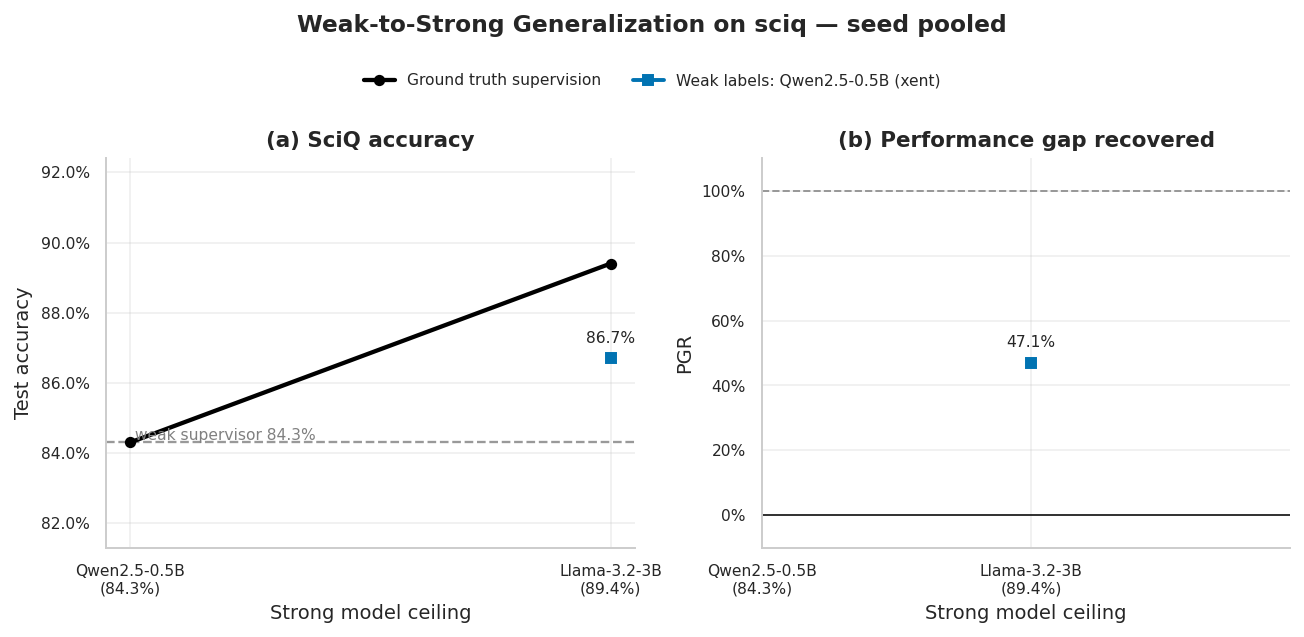

Saved PNG: /Users/sunil/My Files/TARA/Final Project/weak_to_strong_generalization/results/paper_style_plots/sciq_seed_pooled_paper_style.png
Saved PDF: /Users/sunil/My Files/TARA/Final Project/weak_to_strong_generalization/results/paper_style_plots/sciq_seed_pooled_paper_style.pdf


,model_size,supervision,loss,accuracy,weak_model_accuracy,strong_model_accuracy,pgr,n_runs
0,Llama-3.2-3B,Qwen2.5-0.5B,xent,86.70%,84.30%,89.40%,47.06%,1
1,Llama-3.2-3B,ground truth,xent,89.40%,,89.40%,,1
2,Qwen2.5-0.5B,ground truth,xent,84.30%,,84.30%,,2


In [5]:
# Compute Metrics and Render Paper-Style Plots

def add_w2s_metrics(cur_df):
    """
    Adds:
      - strong_model_accuracy
      - weak_model_accuracy
      - pgr
      - supervision label
    """

    cur_df = cur_df.copy()

    # Base runs are ground-truth supervised runs.
    base_df = cur_df[cur_df["weak_model_size"].isna()].copy()

    if base_df.empty:
        raise ValueError("No ground-truth baseline runs found for this dataset.")

    # Mean across seeds if multiple seed baseline runs exist.
    base_accuracies = (
        base_df
        .groupby("model_size", as_index=False)
        .agg(
            accuracy=("accuracy", "mean"),
            seed_count=("seed", "count"),
        )
        .sort_values("accuracy")
    )

    base_accuracy_lookup = dict(
        zip(base_accuracies["model_size"], base_accuracies["accuracy"])
    )

    # Strong model ceiling for every row.
    cur_df["strong_model_accuracy"] = cur_df["model_size"].map(base_accuracy_lookup)

    # Weak model accuracy for W2S rows.
    cur_df["weak_model_accuracy"] = cur_df["weak_model_size"].map(base_accuracy_lookup)

    # PGR only makes sense for W2S rows where strong ceiling > weak supervisor.
    valid_pgr_index = (
        cur_df["weak_model_size"].notna()
        & (cur_df["weak_model_size"] != cur_df["model_size"])
        & cur_df["strong_model_accuracy"].notna()
        & cur_df["weak_model_accuracy"].notna()
        & (cur_df["strong_model_accuracy"] > cur_df["weak_model_accuracy"])
    )

    cur_df["pgr"] = np.nan

    cur_df.loc[valid_pgr_index, "pgr"] = (
        cur_df.loc[valid_pgr_index, "accuracy"]
        - cur_df.loc[valid_pgr_index, "weak_model_accuracy"]
    ) / (
        cur_df.loc[valid_pgr_index, "strong_model_accuracy"]
        - cur_df.loc[valid_pgr_index, "weak_model_accuracy"]
    )

    cur_df["supervision"] = cur_df["weak_model_size"].fillna("ground truth")

    return cur_df, base_accuracies, base_accuracy_lookup


def aggregate_for_plot(plot_df):
    """
    For seed=None, aggregate multiple seeds by median.
    For one seed, this function still returns the same structure.
    """

    group_cols = [
        "ds_name",
        "model_size",
        "weak_model_size",
        "supervision",
        "loss",
        "strong_model_accuracy",
        "weak_model_accuracy",
    ]

    available_group_cols = [c for c in group_cols if c in plot_df.columns]

    agg_df = (
        plot_df
        .groupby(available_group_cols, dropna=False, as_index=False)
        .agg(
            accuracy=("accuracy", "median"),
            pgr=("pgr", "median"),
            n_runs=("seed", "count"),
        )
    )

    return agg_df


def make_paper_style_plot(plot_df, base_accuracies, dataset, seed_label, save_dir):
    """
    Makes a two-panel figure:
      (a) Test accuracy
      (b) Performance gap recovered

    This is closer to the paper than a single lineplot because the paper
    separates accuracy and PGR.
    """

    plot_df = aggregate_for_plot(plot_df)

    # Ground-truth supervised baselines.
    gt_df = plot_df[plot_df["supervision"] == "ground truth"].copy()
    gt_df = gt_df.sort_values("strong_model_accuracy")

    # Weak-to-strong rows.
    w2s_df = plot_df[plot_df["supervision"] != "ground truth"].copy()
    w2s_df = w2s_df.sort_values("strong_model_accuracy")

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(9.2, 3.6),
        sharex=False,
        constrained_layout=True,
    )

    ax_acc, ax_pgr = axes

    # -------------------------
    # Panel A: Accuracy
    # -------------------------

    # Strong ceiling line.
    ax_acc.plot(
        gt_df["strong_model_accuracy"],
        gt_df["accuracy"],
        marker="o",
        linewidth=2.2,
        color="black",
        label="Ground truth supervision",
        zorder=3,
    )

    # Weak-to-strong points/lines by weak supervisor and loss.
    if not w2s_df.empty:
        weak_supervisors = sorted(w2s_df["supervision"].dropna().unique())

        palette = sns.color_palette("colorblind", n_colors=max(len(weak_supervisors), 1))
        color_lookup = {
            supervisor: palette[i]
            for i, supervisor in enumerate(weak_supervisors)
        }

        for (supervisor, loss), sub in w2s_df.groupby(["supervision", "loss"], dropna=False):
            sub = sub.sort_values("strong_model_accuracy")

            label = f"Weak labels: {supervisor}"
            if pd.notna(loss):
                label += f" ({loss})"

            ax_acc.plot(
                sub["strong_model_accuracy"],
                sub["accuracy"],
                marker="s",
                linewidth=2.0,
                linestyle="-",
                color=color_lookup[supervisor],
                label=label,
                zorder=4,
            )

            # Annotate single-point W2S result.
            if len(sub) == 1:
                row = sub.iloc[0]
                ax_acc.annotate(
                    f"{row['accuracy']:.1%}",
                    xy=(row["strong_model_accuracy"], row["accuracy"]),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha="center",
                    fontsize=8,
                )

    # Add weak supervisor horizontal line if available.
    if not w2s_df.empty and "weak_model_accuracy" in w2s_df.columns:
        weak_accs = w2s_df["weak_model_accuracy"].dropna().unique()

        for weak_acc in weak_accs:
            ax_acc.axhline(
                weak_acc,
                linestyle="--",
                linewidth=1.2,
                color="gray",
                alpha=0.8,
                zorder=1,
            )

            ax_acc.text(
                x=gt_df["strong_model_accuracy"].min(),
                y=weak_acc,
                s=f" weak supervisor {weak_acc:.1%}",
                va="bottom",
                ha="left",
                fontsize=8,
                color="gray",
            )

    ax_acc.set_title("(a) SciQ accuracy")
    ax_acc.set_ylabel("Test accuracy")
    ax_acc.set_xlabel("Strong model ceiling")
    ax_acc.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax_acc.grid(True, alpha=0.35)

    # -------------------------
    # Panel B: PGR
    # -------------------------

    ax_pgr.axhline(
        0,
        color="black",
        linewidth=1.0,
        alpha=0.8,
        zorder=1,
    )

    ax_pgr.axhline(
        1,
        color="gray",
        linewidth=1.0,
        linestyle="--",
        alpha=0.8,
        zorder=1,
    )

    if not w2s_df.empty:
        for (supervisor, loss), sub in w2s_df.groupby(["supervision", "loss"], dropna=False):
            sub = sub.dropna(subset=["pgr"]).sort_values("strong_model_accuracy")

            if sub.empty:
                continue

            label = f"Weak labels: {supervisor}"
            if pd.notna(loss):
                label += f" ({loss})"

            ax_pgr.plot(
                sub["strong_model_accuracy"],
                sub["pgr"],
                marker="s",
                linewidth=2.0,
                linestyle="-",
                color=color_lookup[supervisor],
                label=label,
                zorder=4,
            )

            # Annotate PGR.
            if len(sub) == 1:
                row = sub.iloc[0]
                ax_pgr.annotate(
                    f"{row['pgr']:.1%}",
                    xy=(row["strong_model_accuracy"], row["pgr"]),
                    xytext=(0, 8),
                    textcoords="offset points",
                    ha="center",
                    fontsize=8,
                )

    ax_pgr.set_title("(b) Performance gap recovered")
    ax_pgr.set_ylabel("PGR")
    ax_pgr.set_xlabel("Strong model ceiling")
    ax_pgr.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    ax_pgr.set_ylim(-0.1, 1.1)
    ax_pgr.grid(True, alpha=0.35)

    # -------------------------
    # X-axis ticks like original notebook
    # -------------------------

    tick_df = base_accuracies.sort_values("accuracy").copy()

    tick_positions = tick_df["accuracy"].tolist()
    tick_labels = [
        f"{row.model_size}\n({row.accuracy:.1%})"
        for row in tick_df.itertuples()
    ]

    for ax in axes:
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=0)

    # Dynamic y-limits for accuracy panel.
    all_acc_values = plot_df["accuracy"].dropna().tolist()

    if not w2s_df.empty:
        all_acc_values += w2s_df["weak_model_accuracy"].dropna().tolist()

    if all_acc_values:
        ymin = max(0.0, min(all_acc_values) - 0.03)
        ymax = min(1.0, max(all_acc_values) + 0.03)
        ax_acc.set_ylim(ymin, ymax)

    # Shared legend.
    handles, labels = ax_acc.get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.13),
        ncol=2,
        frameon=False,
    )

    fig.suptitle(
        f"Weak-to-Strong Generalization on {dataset} — {seed_label}",
        y=1.22,
        fontsize=12,
        fontweight="bold",
    )

    # Save files.
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    safe_dataset = dataset.replace("/", "-")
    safe_seed = seed_label.replace(" ", "_").replace(":", "")
    png_path = save_dir / f"{safe_dataset}_{safe_seed}_paper_style.png"
    pdf_path = save_dir / f"{safe_dataset}_{safe_seed}_paper_style.pdf"

    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")

    plt.show()

    print(f"Saved PNG: {png_path}")
    print(f"Saved PDF: {pdf_path}")

    # Show compact numerical table below the plot.
    summary_cols = [
        "model_size",
        "supervision",
        "loss",
        "accuracy",
        "weak_model_accuracy",
        "strong_model_accuracy",
        "pgr",
        "n_runs",
    ]

    summary_table = plot_df[[c for c in summary_cols if c in plot_df.columns]].copy()

    for col in ["accuracy", "weak_model_accuracy", "strong_model_accuracy", "pgr"]:
        if col in summary_table.columns:
            summary_table[col] = summary_table[col].map(
                lambda x: f"{x:.2%}" if pd.notna(x) else ""
            )

    display(summary_table)


plot_save_dir = Path(RESULTS_PATH) / PLOT_DIRNAME

datasets = sorted(df["ds_name"].dropna().unique())

for dataset in datasets:
    cur_df = df[df["ds_name"] == dataset].copy()

    cur_df, base_accuracies, base_accuracy_lookup = add_w2s_metrics(cur_df)

    seed_options = [None]

    if PLOT_ALL_SEEDS:
        seed_options += sorted(cur_df["seed"].dropna().unique().tolist())

    for seed in seed_options:
        if seed is None:
            plot_df = cur_df.copy()
            seed_label = "seed pooled"
        else:
            plot_df = cur_df[cur_df["seed"] == seed].copy()
            seed_label = f"seed {seed}"

        print(f"\nDataset: {dataset} | {seed_label}")

        make_paper_style_plot(
            plot_df=plot_df,
            base_accuracies=base_accuracies,
            dataset=dataset,
            seed_label=seed_label,
            save_dir=plot_save_dir,
        )

In [6]:
# Load and Parse Results JSONs — filtered to my Qwen/Llama runs only

def short_model_name(name):
    if not isinstance(name, str):
        return name
    return name.split("/")[-1]

def read_final_eval_accuracy_from_log(run_dir):
    """
    For weak-to-strong runs, results_summary.json can sometimes be stale or overwritten.
    This reads the final eval_accuracy from log.jsonl where available.
    """
    log_file = os.path.join(run_dir, "log.jsonl")
    if not os.path.exists(log_file):
        return None

    final_acc = None
    with open(log_file, "r") as f:
        for line in f:
            try:
                row = json.loads(line)
            except json.JSONDecodeError:
                continue

            if "eval_accuracy" in row:
                final_acc = row["eval_accuracy"]
            elif "accuracy" in row and "loss" not in row:
                final_acc = row["accuracy"]

    return final_acc


MODELS_TO_PLOT_SHORT = {short_model_name(m) for m in MODELS_TO_PLOT}

records = []

for result_filename in glob.glob(os.path.join(RESULTS_PATH, "**/results_summary.json"), recursive=True):
    run_dir = os.path.dirname(result_filename)
    config_file = os.path.join(run_dir, "config.json")

    if not os.path.exists(config_file):
        continue

    with open(config_file, "r") as f:
        config = json.load(f)

    model_short = short_model_name(config.get("model_size"))

    # Only keep your Qwen/Llama models
    if model_short not in MODELS_TO_PLOT_SHORT:
        continue

    if "seed" not in config:
        config["seed"] = 0

    record = config.copy()

    # Flatten weak_model nested config if present
    if "weak_model" in record:
        for k in record["weak_model"]:
            if k == "model_size":
                assert record["weak_model"][k] == record["weak_model_size"]
            record["weak_" + k] = record["weak_model"][k]
        del record["weak_model"]

    with open(result_filename, "r") as f:
        summary = json.load(f)

    record.update(summary)

    # Standardise names
    record["model_size"] = short_model_name(record.get("model_size"))

    if "weak_model_size" in record and isinstance(record["weak_model_size"], str):
        record["weak_model_size"] = short_model_name(record["weak_model_size"])

    # Detect W2S run
    is_w2s_run = "weak_model_size" in record and pd.notna(record["weak_model_size"])

    # Important: for W2S run, prefer log.jsonl final eval accuracy
    if is_w2s_run:
        log_acc = read_final_eval_accuracy_from_log(run_dir)
        if log_acc is not None:
            record["accuracy"] = log_acc
            record["accuracy_source"] = "log.jsonl"
        else:
            record["accuracy_source"] = "results_summary.json"
    else:
        record["accuracy_source"] = "results_summary.json"

    records.append(record)

df = pd.DataFrame.from_records(records)

if df.empty:
    raise ValueError("No Qwen/Llama results found. Check RESULTS_PATH and MODELS_TO_PLOT.")

if "weak_model_size" not in df.columns:
    df["weak_model_size"] = np.nan

# Clean sort order
model_order = {
    "Qwen2.5-0.5B": 0,
    "Llama-3.2-3B": 1,
}

df["model_order"] = df["model_size"].map(model_order).fillna(99)

df = df.sort_values(["ds_name", "model_order", "weak_model_size", "seed"])

display(df[[
    "ds_name",
    "model_size",
    "weak_model_size",
    "loss",
    "seed",
    "accuracy",
    "accuracy_source",
]])

,ds_name,model_size,weak_model_size,loss,seed,accuracy,accuracy_source
0,sciq,Qwen2.5-0.5B,NaN,xent,0,0.852,results_summary.json
3,sciq,Qwen2.5-0.5B,NaN,xent,0,0.834,results_summary.json
2,sciq,Llama-3.2-3B,Qwen2.5-0.5B,xent,0,0.867,log.jsonl
1,sciq,Llama-3.2-3B,NaN,xent,0,0.894,results_summary.json


Dataset: sciq (seed: None)


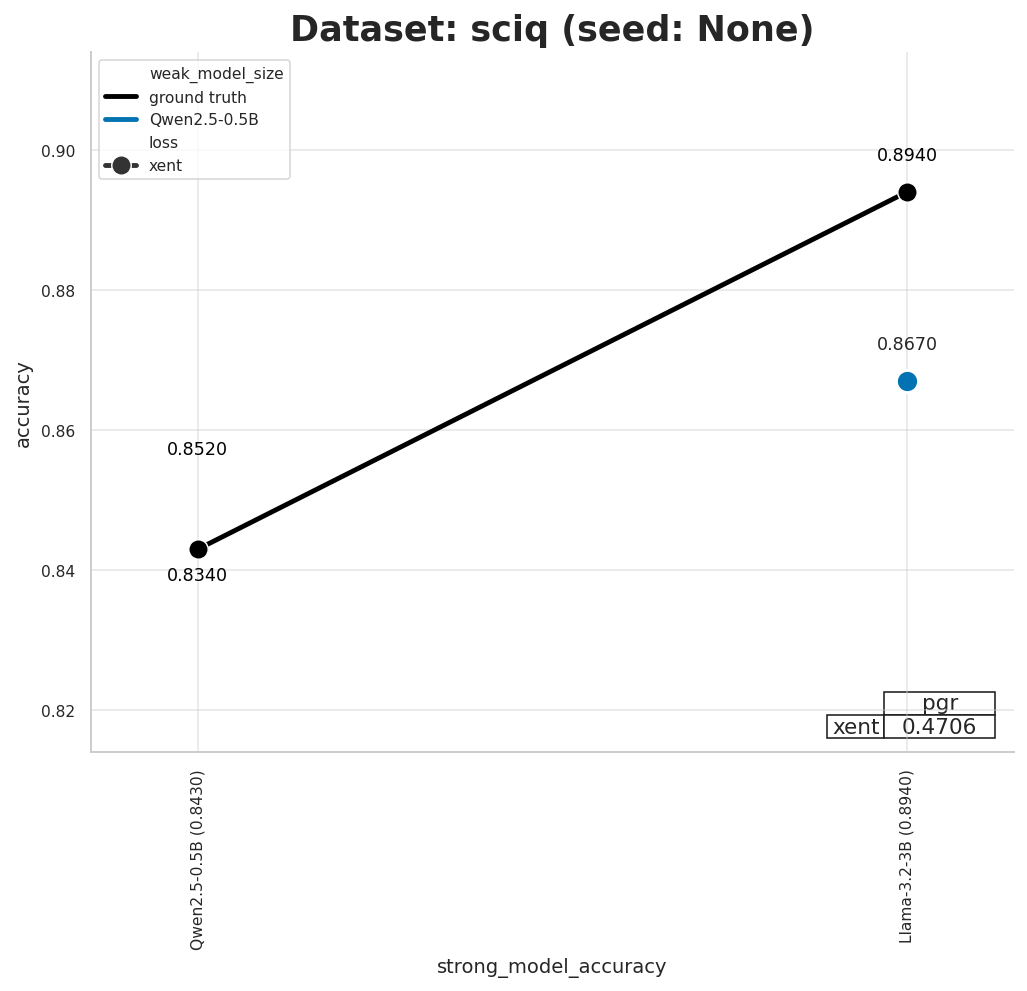

Saved: sciq_my_models_original_style.png


In [7]:
# Compute Metrics and Render Original-Style Plot for My Models

datasets = df.ds_name.unique()

for dataset in datasets:
    cur_df = df[df.ds_name == dataset].copy()

    # Base accuracies = ground-truth supervised runs
    base_accuracies = (
        cur_df[cur_df["weak_model_size"].isna()]
        .groupby("model_size")
        .agg({"accuracy": "mean", "seed": "count"})
        .sort_values("accuracy")
    )

    base_accuracy_lookup = base_accuracies["accuracy"].to_dict()
    base_accuracies = base_accuracies.reset_index()

    # Attach strong ceiling and weak supervisor accuracy
    cur_df["strong_model_accuracy"] = cur_df["model_size"].apply(
        lambda x: base_accuracy_lookup.get(x, np.nan)
    )

    cur_df.loc[cur_df["weak_model_size"].notna(), "weak_model_accuracy"] = (
        cur_df.loc[cur_df["weak_model_size"].notna(), "weak_model_size"]
        .apply(lambda x: base_accuracy_lookup.get(x, np.nan))
    )

    # PGR calculation
    valid_pgr_index = (
        cur_df["weak_model_size"].notna()
        & (cur_df["weak_model_size"] != cur_df["model_size"])
        & cur_df["strong_model_accuracy"].notna()
        & cur_df["weak_model_accuracy"].notna()
        & (cur_df["strong_model_accuracy"] > cur_df["weak_model_accuracy"])
    )

    cur_df["pgr"] = np.nan

    cur_df.loc[valid_pgr_index, "pgr"] = (
        cur_df.loc[valid_pgr_index, "accuracy"]
        - cur_df.loc[valid_pgr_index, "weak_model_accuracy"]
    ) / (
        cur_df.loc[valid_pgr_index, "strong_model_accuracy"]
        - cur_df.loc[valid_pgr_index, "weak_model_accuracy"]
    )

    # Match original notebook convention
    cur_df.loc[cur_df["weak_model_size"].isna(), "weak_model_size"] = "ground truth"

    for seed in [None] + (sorted(cur_df["seed"].unique().tolist()) if PLOT_ALL_SEEDS else []):
        plot_df = cur_df.copy()

        if seed is not None:
            plot_df = plot_df[plot_df["seed"] == seed]

        plot_df = plot_df.sort_values(["strong_model_accuracy", "weak_model_size"])

        print(f"Dataset: {dataset} (seed: {seed})")

        # PGR table like original plot
        pgr_results = (
            plot_df[plot_df["pgr"].notna()]
            .groupby(["loss"])
            .aggregate({"pgr": "median"})
        )

        # Original-style colour handling
        weak_models = plot_df["weak_model_size"].unique().tolist()

        palette = sns.color_palette(
            "colorblind",
            n_colors=max(len([m for m in weak_models if m != "ground truth"]), 1)
        )

        color_dict = {}
        for model in weak_models:
            if model == "ground truth":
                color_dict[model] = "black"
            else:
                color_dict[model] = palette.pop(0)

        plt.figure(figsize=(8.5, 6.5))

        ax = sns.lineplot(
            data=plot_df,
            x="strong_model_accuracy",
            y="accuracy",
            hue="weak_model_size",
            style="loss",
            markers=True,
            dashes=True,
            linewidth=2.5,
            markersize=10,
            palette=color_dict,
            errorbar=None,
        )

        # If W2S is only one point, make sure it is visibly plotted
        w2s_points = plot_df[plot_df["weak_model_size"] != "ground truth"]

        for _, row in w2s_points.iterrows():
            plt.scatter(
                row["strong_model_accuracy"],
                row["accuracy"],
                s=130,
                edgecolor="white",
                linewidth=1.5,
                color=color_dict[row["weak_model_size"]],
                zorder=5,
            )

            plt.text(
                row["strong_model_accuracy"],
                row["accuracy"] + 0.004,
                f"{row['accuracy']:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )

        # Annotate ground truth points
        gt_points = plot_df[plot_df["weak_model_size"] == "ground truth"]

        for _, row in gt_points.iterrows():
            plt.text(
                row["strong_model_accuracy"],
                row["accuracy"] + 0.004,
                f"{row['accuracy']:.4f}",
                ha="center",
                va="bottom",
                fontsize=9,
                color="black",
            )

        # PGR table in lower right, like original plot
        if not pgr_results.empty:
            pd.plotting.table(
                plt.gca(),
                pgr_results.round(4),
                loc="lower right",
                colWidths=[0.12, 0.12],
                cellLoc="center",
                rowLoc="center",
            )

        # Original-style x ticks: model name + strong ceiling accuracy
        plt.xticks(
            ticks=base_accuracies["accuracy"],
            labels=[
                f"{e} ({base_accuracy_lookup[e]:.4f})"
                for e in base_accuracies["model_size"]
            ],
            rotation=90,
        )

        plt.xlabel("strong_model_accuracy")
        plt.ylabel("accuracy")
        plt.title(f"Dataset: {dataset} (seed: {seed})", fontsize=18)

        # Tighten axis around your two-model result
        all_x = plot_df["strong_model_accuracy"].dropna()
        all_y = plot_df["accuracy"].dropna()

        if len(all_x) > 0:
            x_pad = max((all_x.max() - all_x.min()) * 0.15, 0.005)
            plt.xlim(all_x.min() - x_pad, all_x.max() + x_pad)

        if len(all_y) > 0:
            y_min = min(all_y.min(), plot_df.get("weak_model_accuracy", all_y).min()) - 0.02
            y_max = max(all_y.max(), plot_df.get("weak_model_accuracy", all_y).max()) + 0.02
            plt.ylim(y_min, y_max)

        plt.legend(loc="upper left", frameon=True)
        plt.grid(True, alpha=0.5)

        suffix = ""
        if seed is not None:
            suffix = f"_{seed}"

        output_name = f"{dataset.replace('/', '-')}_my_models_original_style{suffix}.png"

        plt.savefig(output_name, dpi=300, bbox_inches="tight")
        plt.show()

        print(f"Saved: {output_name}")


Raw baseline runs before deduplication:


,ds_name,model_size,seed,accuracy,accuracy_source
0,sciq,Qwen2.5-0.5B,0,0.852,results_summary.json
3,sciq,Qwen2.5-0.5B,0,0.834,results_summary.json
1,sciq,Llama-3.2-3B,0,0.894,results_summary.json



Baseline runs used for plotting:


,ds_name,model_size,seed,accuracy,accuracy_source
1,sciq,Llama-3.2-3B,0,0.894,results_summary.json
0,sciq,Qwen2.5-0.5B,0,0.852,results_summary.json


Dataset: sciq (seed: None)


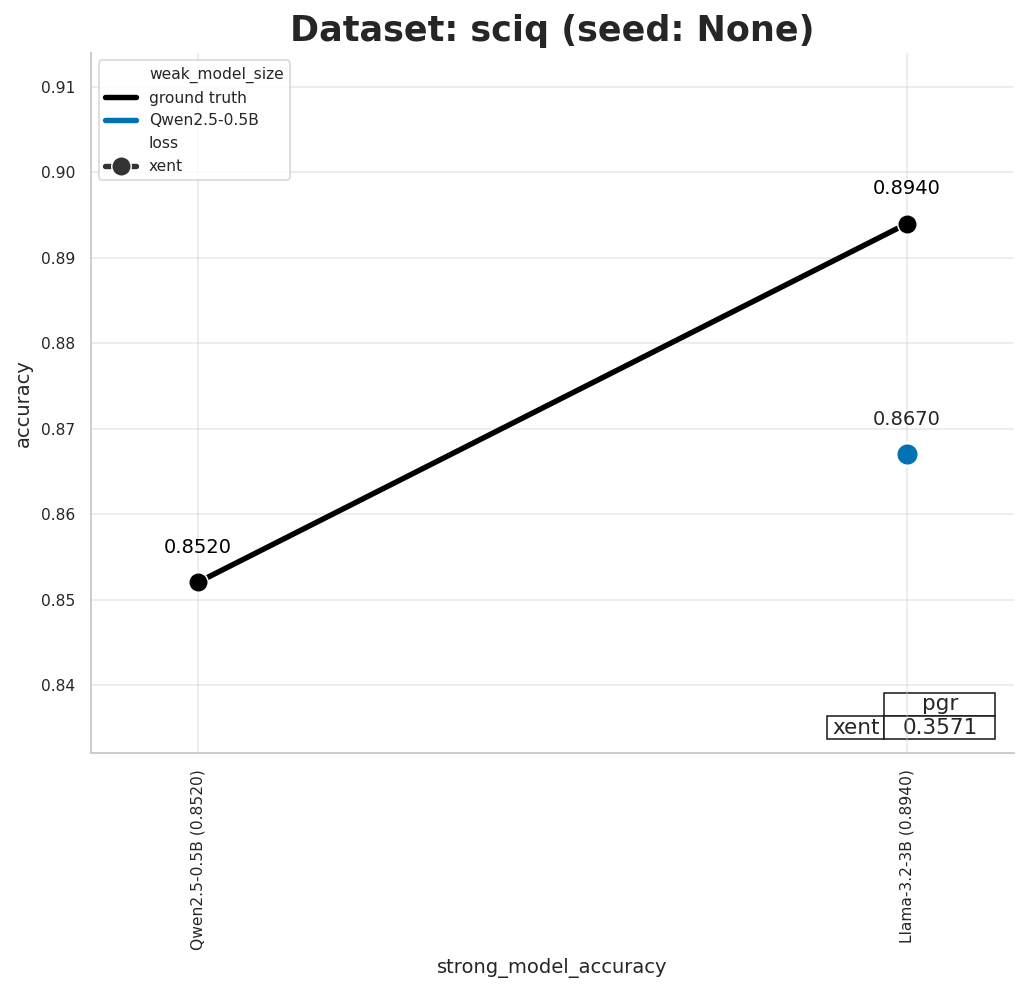

Saved: sciq_my_models_original_style_deduped.png


In [8]:
# Compute Metrics and Render Original-Style Plot for My Models
# Deduplicates repeated baseline runs so old/failed runs do not distort the plot.

DEDUPLICATE_BASELINES = True

# Options:
# "max" = keep highest baseline accuracy for each model
# "latest" = keep latest modified results_summary.json
# "mean" = average all baseline runs, only use if duplicates are real repeated seeds
BASELINE_DEDUP_METHOD = "max"

datasets = df.ds_name.unique()

for dataset in datasets:
    cur_df = df[df.ds_name == dataset].copy()

    # Separate baseline and W2S rows
    baseline_df = cur_df[cur_df["weak_model_size"].isna()].copy()
    w2s_df = cur_df[cur_df["weak_model_size"].notna()].copy()

    # Add modified time for optional latest-run selection
    if "run_dir" in baseline_df.columns:
        baseline_df["mtime"] = baseline_df["run_dir"].apply(
            lambda p: os.path.getmtime(os.path.join(p, "results_summary.json"))
            if os.path.exists(os.path.join(p, "results_summary.json")) else 0
        )
    else:
        baseline_df["mtime"] = 0

    print("\nRaw baseline runs before deduplication:")
    display(
        baseline_df[[
            "ds_name",
            "model_size",
            "seed",
            "accuracy",
            "accuracy_source",
            "run_dir"
        ]]
        if "run_dir" in baseline_df.columns
        else baseline_df[["ds_name", "model_size", "seed", "accuracy", "accuracy_source"]]
    )

    # Deduplicate baseline runs
    if DEDUPLICATE_BASELINES:
        if BASELINE_DEDUP_METHOD == "max":
            baseline_df = (
                baseline_df
                .sort_values(["model_size", "accuracy"])
                .groupby("model_size", as_index=False)
                .tail(1)
            )

        elif BASELINE_DEDUP_METHOD == "latest":
            baseline_df = (
                baseline_df
                .sort_values(["model_size", "mtime"])
                .groupby("model_size", as_index=False)
                .tail(1)
            )

        elif BASELINE_DEDUP_METHOD == "mean":
            baseline_df = (
                baseline_df
                .groupby(["ds_name", "model_size", "loss"], as_index=False)
                .agg({
                    "accuracy": "mean",
                    "seed": "count"
                })
            )
            baseline_df["weak_model_size"] = np.nan
            baseline_df["accuracy_source"] = "mean_over_duplicate_baselines"

        else:
            raise ValueError("BASELINE_DEDUP_METHOD must be 'max', 'latest', or 'mean'.")

    print("\nBaseline runs used for plotting:")
    display(
        baseline_df[[
            "ds_name",
            "model_size",
            "seed",
            "accuracy",
            "accuracy_source"
        ]]
        if "seed" in baseline_df.columns
        else baseline_df[["ds_name", "model_size", "accuracy", "accuracy_source"]]
    )

    # Rebuild cur_df after deduplication
    cur_df = pd.concat([baseline_df, w2s_df], ignore_index=True)

    # Base accuracies = selected ground-truth supervised runs
    base_accuracies = (
        baseline_df
        .groupby("model_size")
        .agg({"accuracy": "mean"})
        .sort_values("accuracy")
    )

    base_accuracy_lookup = base_accuracies["accuracy"].to_dict()
    base_accuracies = base_accuracies.reset_index()

    # Attach strong ceiling and weak supervisor accuracy
    cur_df["strong_model_accuracy"] = cur_df["model_size"].apply(
        lambda x: base_accuracy_lookup.get(x, np.nan)
    )

    cur_df.loc[cur_df["weak_model_size"].notna(), "weak_model_accuracy"] = (
        cur_df.loc[cur_df["weak_model_size"].notna(), "weak_model_size"]
        .apply(lambda x: base_accuracy_lookup.get(x, np.nan))
    )

    # PGR calculation
    valid_pgr_index = (
        cur_df["weak_model_size"].notna()
        & (cur_df["weak_model_size"] != cur_df["model_size"])
        & cur_df["strong_model_accuracy"].notna()
        & cur_df["weak_model_accuracy"].notna()
        & (cur_df["strong_model_accuracy"] > cur_df["weak_model_accuracy"])
    )

    cur_df["pgr"] = np.nan

    cur_df.loc[valid_pgr_index, "pgr"] = (
        cur_df.loc[valid_pgr_index, "accuracy"]
        - cur_df.loc[valid_pgr_index, "weak_model_accuracy"]
    ) / (
        cur_df.loc[valid_pgr_index, "strong_model_accuracy"]
        - cur_df.loc[valid_pgr_index, "weak_model_accuracy"]
    )

    # Match original notebook convention
    cur_df.loc[cur_df["weak_model_size"].isna(), "weak_model_size"] = "ground truth"

    for seed in [None] + (sorted(cur_df["seed"].dropna().unique().tolist()) if PLOT_ALL_SEEDS else []):
        plot_df = cur_df.copy()

        if seed is not None:
            plot_df = plot_df[plot_df["seed"] == seed]

        plot_df = plot_df.sort_values(["strong_model_accuracy", "weak_model_size"])

        print(f"Dataset: {dataset} (seed: {seed})")

        pgr_results = (
            plot_df[plot_df["pgr"].notna()]
            .groupby(["loss"])
            .aggregate({"pgr": "median"})
        )

        weak_models = plot_df["weak_model_size"].unique().tolist()

        palette = sns.color_palette(
            "colorblind",
            n_colors=max(len([m for m in weak_models if m != "ground truth"]), 1)
        )

        color_dict = {}
        for model in weak_models:
            if model == "ground truth":
                color_dict[model] = "black"
            else:
                color_dict[model] = palette.pop(0)

        plt.figure(figsize=(8.5, 6.5))

        ax = sns.lineplot(
            data=plot_df,
            x="strong_model_accuracy",
            y="accuracy",
            hue="weak_model_size",
            style="loss",
            markers=True,
            dashes=True,
            linewidth=2.8,
            markersize=10,
            palette=color_dict,
            errorbar=None,
        )

        # Highlight W2S point
        w2s_points = plot_df[plot_df["weak_model_size"] != "ground truth"]

        for _, row in w2s_points.iterrows():
            plt.scatter(
                row["strong_model_accuracy"],
                row["accuracy"],
                s=140,
                edgecolor="white",
                linewidth=1.5,
                color=color_dict[row["weak_model_size"]],
                zorder=5,
            )

            plt.text(
                row["strong_model_accuracy"],
                row["accuracy"] + 0.003,
                f"{row['accuracy']:.4f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

        # Annotate ground truth points
        gt_points = plot_df[plot_df["weak_model_size"] == "ground truth"]

        for _, row in gt_points.iterrows():
            plt.text(
                row["strong_model_accuracy"],
                row["accuracy"] + 0.003,
                f"{row['accuracy']:.4f}",
                ha="center",
                va="bottom",
                fontsize=10,
                color="black",
            )

        # PGR table in lower right
        if not pgr_results.empty:
            pd.plotting.table(
                plt.gca(),
                pgr_results.round(4),
                loc="lower right",
                colWidths=[0.12, 0.12],
                cellLoc="center",
                rowLoc="center",
            )

        # X ticks: model name + selected strong ceiling accuracy
        plt.xticks(
            ticks=base_accuracies["accuracy"],
            labels=[
                f"{e} ({base_accuracy_lookup[e]:.4f})"
                for e in base_accuracies["model_size"]
            ],
            rotation=90,
        )

        plt.xlabel("strong_model_accuracy")
        plt.ylabel("accuracy")
        plt.title(f"Dataset: {dataset} (seed: {seed})", fontsize=18, fontweight="bold")

        all_x = plot_df["strong_model_accuracy"].dropna()
        all_y = plot_df["accuracy"].dropna()

        if len(all_x) > 0:
            x_pad = max((all_x.max() - all_x.min()) * 0.15, 0.005)
            plt.xlim(all_x.min() - x_pad, all_x.max() + x_pad)

        if len(all_y) > 0:
            y_values = list(all_y)

            if "weak_model_accuracy" in plot_df.columns:
                y_values += list(plot_df["weak_model_accuracy"].dropna())

            y_min = min(y_values) - 0.02
            y_max = max(y_values) + 0.02

            plt.ylim(y_min, y_max)

        plt.legend(loc="upper left", frameon=True)
        plt.grid(True, alpha=0.45)

        suffix = ""
        if seed is not None:
            suffix = f"_{seed}"

        output_name = f"{dataset.replace('/', '-')}_my_models_original_style_deduped{suffix}.png"

        plt.savefig(output_name, dpi=300, bbox_inches="tight")
        plt.show()

        print(f"Saved: {output_name}")